In [17]:
# Merge all benchmark result files into one
# Expected columns in each file (case-insensitive): engine, query, run, sf1, sf10

from pathlib import Path
import pandas as pd
import re

FOLDER = Path("benchmark_test_results")
OUT_CSV = FOLDER / "all_engines_sf1_sf10_merged.csv"
OUT_XLSX = FOLDER / "all_engines_sf1_sf10_merged.xlsx"

# If you have old .xls files you may need:
# !pip install xlrd==2.0.1
# For .xlsx:
# !pip install openpyxl

def read_any(path: Path) -> pd.DataFrame:
    """Read CSV / XLS / XLSX with pandas."""
    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path)
    elif suffix in (".xls", ".xlsx"):
        # Prefer openpyxl for xlsx; xlrd for xls (if available)
        engine = "openpyxl" if suffix == ".xlsx" else None
        try:
            return pd.read_excel(path, engine=engine)
        except Exception:
            # Fallback without specifying engine
            return pd.read_excel(path)
    else:
        raise ValueError(f"Unsupported file type: {path.name}")

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Lower/strip col names and keep only the 5 required columns."""
    df = df.copy()
    df.columns = [c.strip().lower() for c in df.columns]

    # Some safety renames (only if needed)
    rename_map = {
        "sf_1": "sf1",
        "sf_10": "sf10",
    }
    df.rename(columns=rename_map, inplace=True)

    required = ["engine", "query", "run", "sf1", "sf10"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns {missing} in input frame with columns {list(df.columns)}")

    # Select and enforce dtypes
    out = df[required].copy()
    out["engine"] = out["engine"].astype(str)
    out["query"] = out["query"].astype(str)
    # run can be float in some files; coerce to Int64 (nullable)
    out["run"] = pd.to_numeric(out["run"], errors="coerce").astype("Int64")
    out["sf1"] = pd.to_numeric(out["sf1"], errors="coerce")
    out["sf10"] = pd.to_numeric(out["sf10"], errors="coerce")
    return out

def query_order_key(q: str) -> tuple:
    """
    Sort key for queries like 'q01.sql' -> (1, 'q01.sql')
    Keeps a stable tiebreaker with the original string.
    """
    if not isinstance(q, str):
        return (float("inf"), str(q))
    m = re.search(r"q(\d+)", q.lower())
    num = int(m.group(1)) if m else 10**9
    return (num, q)

# Gather files
files = sorted(
    [p for p in FOLDER.iterdir() if p.suffix.lower() in (".csv", ".xls", ".xlsx") and not p.name.startswith("~")]
)

if not files:
    raise SystemExit(f"No CSV/XLS/XLSX files found in {FOLDER.resolve()}")

frames = []
for f in files:
    try:
        df = read_any(f)
        df = normalize_columns(df)
        frames.append(df)
        print(f"Loaded: {f.name}  -> {len(df)} rows")
    except Exception as e:
        print(f"Skipping {f.name}: {e}")

if not frames:
    raise SystemExit("No valid files to merge after filtering.")

merged = pd.concat(frames, ignore_index=True)

# Deduplicate exact duplicates (if any)
merged.drop_duplicates(subset=["engine", "query", "run", "sf1", "sf10"], inplace=True)

# Sort nicely: engine, query number, run
merged.sort_values(
    by=["engine", "query", "run"],
    key=lambda col: col.map(query_order_key) if col.name == "query" else col,
    inplace=True
)

# Save outputs
merged.to_csv(OUT_CSV, index=False)
with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as xw:
    merged.to_excel(xw, sheet_name="merged", index=False)

print(f"\nSaved CSV:  {OUT_CSV}")
print(f"Saved XLSX: {OUT_XLSX}")
print(f"Total rows merged: {len(merged)}")

# Quick peek
display(merged.head(20))


Loaded: Combined_sf1_sf10_by_engine_query_run.csv  -> 540 rows
Loaded: merged_all_engines_sf1_sf10.csv  -> 90 rows
Loaded: merged_dremio_sf1_sf10.csv  -> 90 rows
Loaded: merged_drill_sf1_sf10.csv  -> 90 rows
Loaded: merged_presto-velox_sf1_sf10.csv  -> 90 rows
Loaded: phoenix_sf1_first3runs_q01_q30_with_q22_placeholders.csv  -> 90 rows

Saved CSV:  benchmark_test_results\all_engines_sf1_sf10_merged.csv
Saved XLSX: benchmark_test_results\all_engines_sf1_sf10_merged.xlsx
Total rows merged: 990


,engine,query,run,sf1,sf10
0,clickhouse,q01.sql,1,0.791819,1.598197
1,clickhouse,q01.sql,2,0.511646,0.558539
2,clickhouse,q01.sql,3,0.522538,0.688495
18,clickhouse,q02.sql,1,0.267112,1.616819
19,clickhouse,q02.sql,2,0.254012,0.300460
20,clickhouse,q02.sql,3,0.245619,0.365538
36,clickhouse,q03.sql,1,0.388160,0.498992
37,clickhouse,q03.sql,2,0.363646,0.343782
38,clickhouse,q03.sql,3,0.343200,0.374914
54,clickhouse,q04.sql,1,0.173972,0.564213


Saved: benchmark_test_results\geom_mean_sf1_shaded.png


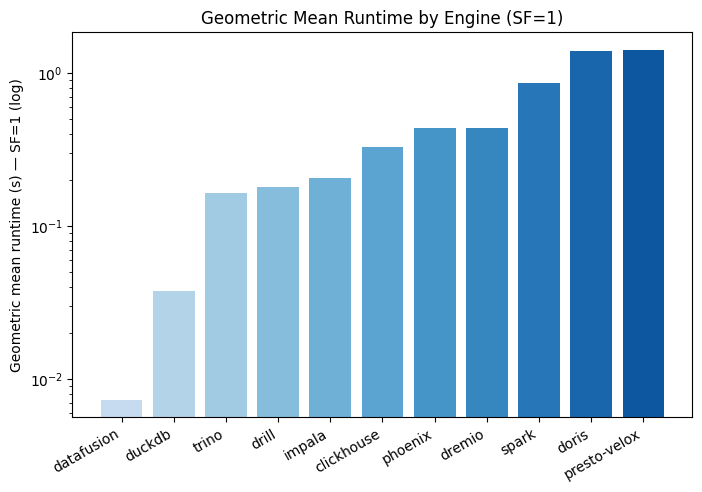

Saved: benchmark_test_results\geom_mean_sf10_shaded.png


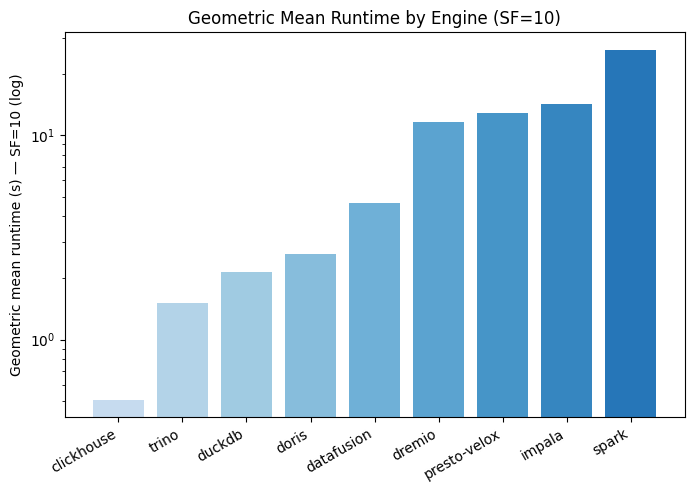

Saved: benchmark_test_results\scaleup_ratio_shaded.png


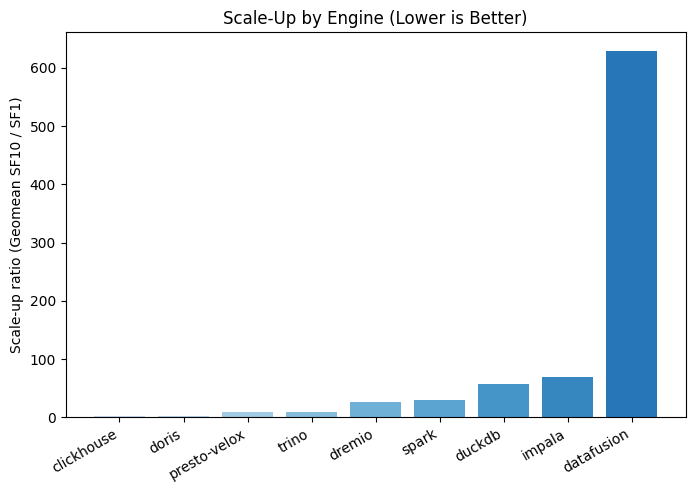

Saved: benchmark_test_results\boxplot_sf10_shaded.png


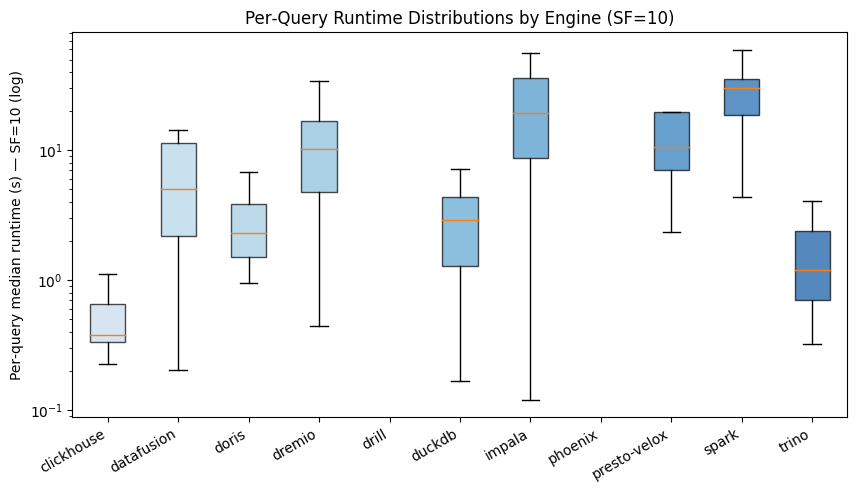

In [41]:
# Cohesive, non‑vibrant colour scheme using a single base colour
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

DATA_DIR   = "benchmark_test_results"
MERGED_CSV = os.path.join(DATA_DIR, "all_engines_sf1_sf10_merged.csv")

df = pd.read_csv(MERGED_CSV)
df["engine"] = df["engine"].astype(str)
df["query"]  = df["query"].astype(str)
df["run"]    = pd.to_numeric(df["run"], errors="coerce").astype("Int64")
df["sf1"]    = pd.to_numeric(df["sf1"], errors="coerce")
df["sf10"]   = pd.to_numeric(df["sf10"], errors="coerce")

df = df[df["run"].isin([1, 2, 3])].copy()

def _qnum(q):
    try: return int(q.lower().replace("q","").split(".")[0])
    except Exception: return 9999
df["qnum"] = df["query"].map(_qnum)

per_query = (
    df.sort_values(["engine","qnum","run"])
      .groupby(["engine","query","qnum"], as_index=False)
      .agg(sf1_med=("sf1","median"), sf10_med=("sf10","median"))
)

def geometric_mean(series):
    x = pd.to_numeric(series, errors="coerce")
    x = x[(x > 0) & np.isfinite(x)]
    return float(np.exp(np.log(x).mean())) if len(x) else np.nan

geo_sf1  = (per_query.groupby("engine", as_index=False)["sf1_med"]
                      .apply(geometric_mean).rename(columns={"sf1_med":"geomean_sf1"})
            ).sort_values("geomean_sf1")
geo_sf10 = (per_query.groupby("engine", as_index=False)["sf10_med"]
                      .apply(geometric_mean).rename(columns={"sf10_med":"geomean_sf10"})
            ).sort_values("geomean_sf10")

scaleup = pd.merge(geo_sf1, geo_sf10, on="engine")
scaleup["scaleup_ratio"] = scaleup["geomean_sf10"] / scaleup["geomean_sf1"]
scaleup_sorted = scaleup.sort_values("scaleup_ratio")

box_sf10 = per_query.pivot_table(index="engine", values="sf10_med", aggfunc=list)
data_sf10 = [pd.Series(vals).dropna().values for vals in box_sf10["sf10_med"]]
labels_sf10 = box_sf10.index.tolist()

def save_and_show(fig, filename):
    path = os.path.join(DATA_DIR, filename)
    fig.savefig(path, dpi=600, bbox_inches="tight")
    print(f"Saved: {path}")
    plt.show()

# Choose your base palette: 'Blues', 'Greens', 'Purples', etc.
base_palette = "Blues"
n_engines = max(len(geo_sf1), len(labels_sf10))
cmap = matplotlib.colormaps.get_cmap(base_palette)
# Pick a mid-range of the palette to avoid extremes (lightest/darkest)
shades = cmap(np.linspace(0.25, 0.85, n_engines))

# Geometric mean SF1
fig = plt.figure(figsize=(8,5))
plt.bar(geo_sf1["engine"], geo_sf1["geomean_sf1"], color=shades[:len(geo_sf1)])
plt.yscale("log")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Geometric mean runtime (s) — SF=1 (log)")
plt.title("Geometric Mean Runtime by Engine (SF=1)")
save_and_show(fig, "geom_mean_sf1_shaded.png")
plt.close(fig)

# Geometric mean SF10
fig = plt.figure(figsize=(8,5))
plt.bar(geo_sf10["engine"], geo_sf10["geomean_sf10"], color=shades[:len(geo_sf10)])
plt.yscale("log")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Geometric mean runtime (s) — SF=10 (log)")
plt.title("Geometric Mean Runtime by Engine (SF=10)")
save_and_show(fig, "geom_mean_sf10_shaded.png")
plt.close(fig)

# Scale-up ratio
fig = plt.figure(figsize=(8,5))
plt.bar(scaleup_sorted["engine"], scaleup_sorted["scaleup_ratio"],
        color=shades[:len(scaleup_sorted)])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Scale‑up ratio (Geomean SF10 / SF1)")
plt.title("Scale‑Up by Engine (Lower is Better)")
save_and_show(fig, "scaleup_ratio_shaded.png")
plt.close(fig)

# Boxplot SF10 medians with matching shades
fig = plt.figure(figsize=(10,5))
bp = plt.boxplot(data_sf10, labels=labels_sf10, showfliers=False, patch_artist=True)
for i, box in enumerate(bp['boxes']):
    box.set(facecolor=shades[i % n_engines], alpha=0.7)
plt.yscale("log")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Per‑query median runtime (s) — SF=10 (log)")
plt.title("Per‑Query Runtime Distributions by Engine (SF=10)")
save_and_show(fig, "boxplot_sf10_shaded.png")
plt.close(fig)
